In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
data_seq = pd.read_csv('pd_render_seq.csv')
data_par = pd.read_csv('pd_render_par.csv')
data_cs = pd.read_csv('pd_render_cs.csv')

In [13]:
# Pick smallest and 4 largest
sorted_counts = sorted(data_seq["particle_count"])
special_labels = [sorted_counts[0]] + sorted_counts[-4:]

def custom_formatter(x, _):
    if x in special_labels:
        return f"$2^{{{int(np.log2(x))}}}$"
    else:
        return "" 

# Render Time

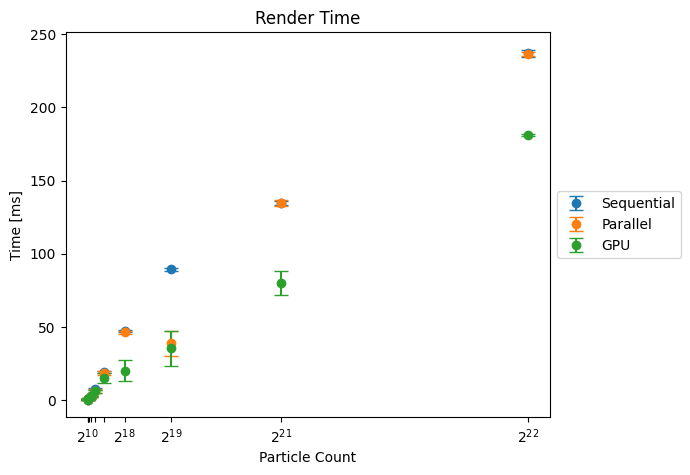

In [14]:

fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_render"], data_seq["avg_time_render_err"], label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_render"], data_par["avg_time_render_err"], label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_render"], data_cs["avg_time_render_err"], label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Render Time")

axs.set_xticks(data_seq["particle_count"])
axs.xaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("render_time.svg", format="svg")
plt.show()

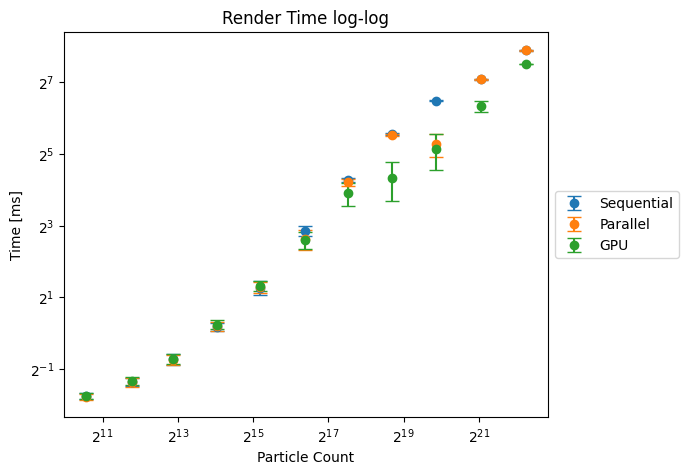

In [15]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_render"], data_seq["avg_time_render_err"], label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_render"], data_par["avg_time_render_err"], label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_render"], data_cs["avg_time_render_err"], label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Render Time log-log")

axs.set_xscale("log", base=2)
axs.set_yscale("log", base=2)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("render_time_log.svg", format="svg")
plt.show()

# Compute time

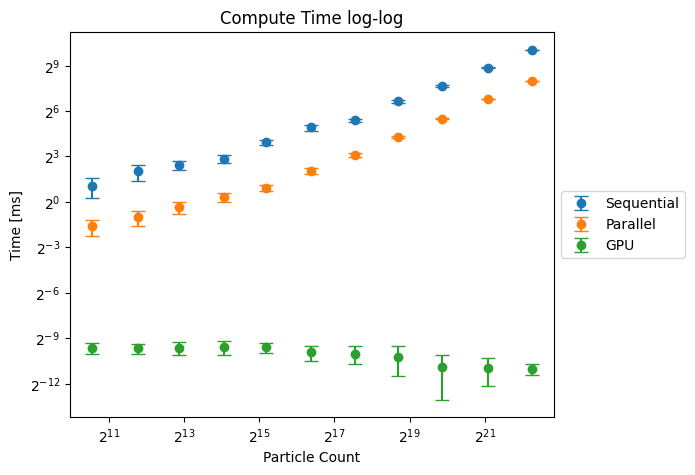

In [16]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_compute_cpu"], yerr=data_seq["avg_time_compute_cpu_err"], label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_compute_cpu"]/8, yerr=data_par["avg_time_compute_cpu_err"]/8, label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_compute"], yerr=data_cs["avg_time_compute_err"], label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Compute Time log-log")

axs.set_xscale("log", base=2)
axs.set_yscale("log", base=2)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("compute_time_log.svg", format="svg")
plt.show()

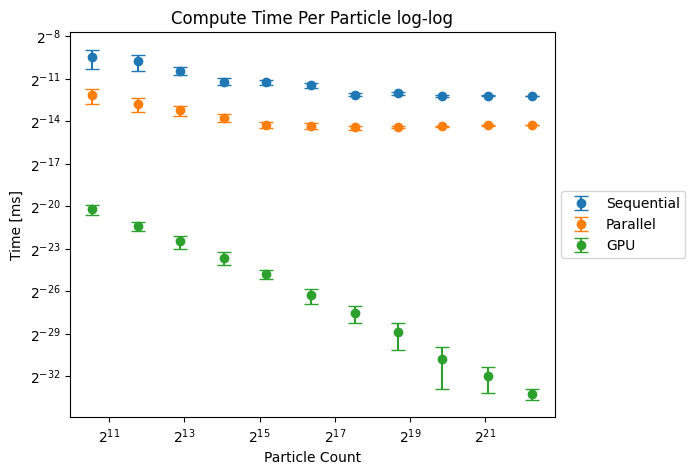

In [17]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_per_particle_compute_cpu"], yerr=data_seq["avg_time_per_particle_compute_cpu_err"], label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_per_particle_compute_cpu"]/8, yerr=data_par["avg_time_per_particle_compute_cpu_err"]/8, label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_per_particle_compute"], yerr=data_cs["avg_time_per_particle_compute_err"], label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Compute Time Per Particle log-log")

axs.set_xscale("log", base=2)
axs.set_yscale("log", base=2)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("compute_time_pp_log.svg", format="svg")
plt.show()

# Application Cycle Time

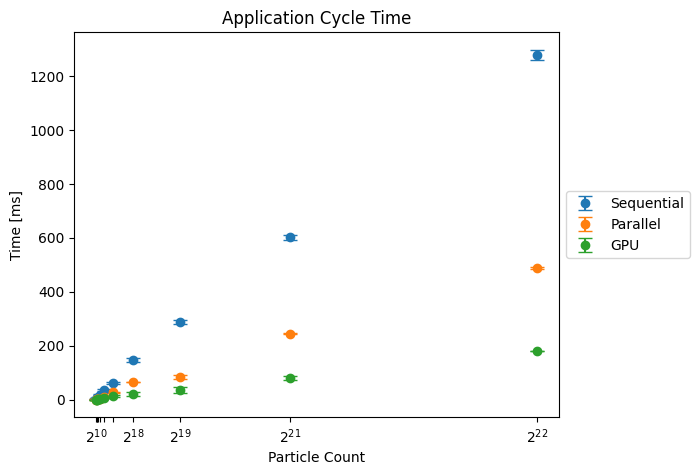

In [18]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_compute_cpu"] + data_seq["avg_time_render"], np.sqrt(data_seq["avg_time_compute_cpu_err"]**2 + data_seq["avg_time_render_err"]**2), label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_compute_cpu"]/8 + data_par["avg_time_render"], np.sqrt((data_par["avg_time_compute_cpu_err"]/8)**2 + data_par["avg_time_render_err"]**2), label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_compute"] + data_cs["avg_time_render"], np.sqrt(data_cs["avg_time_compute_err"]**2 + data_cs["avg_time_render_err"]**2), label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Application Cycle Time")

axs.set_xticks(data_seq["particle_count"])
axs.xaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("app_cycle_time.svg", format="svg")
plt.show()


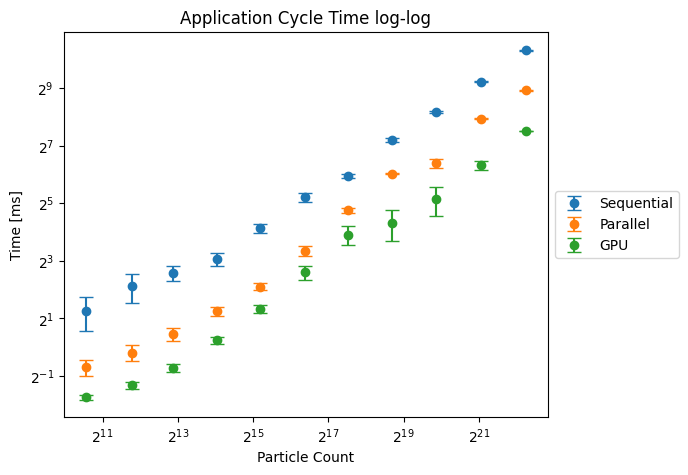

In [19]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_compute_cpu"] + data_seq["avg_time_render"], np.sqrt(data_seq["avg_time_compute_cpu_err"]**2 + data_seq["avg_time_render_err"]**2), label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_compute_cpu"]/8 + data_par["avg_time_render"], np.sqrt((data_par["avg_time_compute_cpu_err"]/8)**2 + data_par["avg_time_render_err"]**2), label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_compute"] + data_cs["avg_time_render"], np.sqrt(data_cs["avg_time_compute_err"]**2 + data_cs["avg_time_render_err"]**2), label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Application Cycle Time log-log")

axs.set_xscale("log", base=2)
axs.set_yscale("log", base=2)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("app_cycle_time_log.svg", format="svg")
plt.show()


# Wall Clock time

In [20]:
wall_seq = pd.read_csv('wall_seq.csv')
wall_par = pd.read_csv('wall_par.csv')
wall_cs = pd.read_csv('wall_cs.csv')

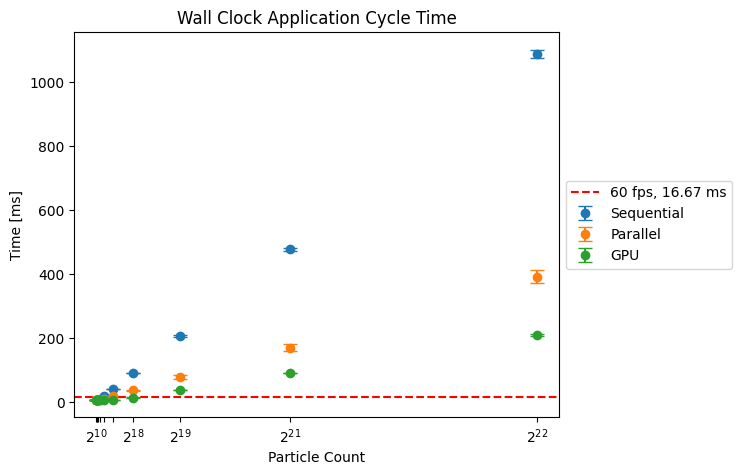

In [21]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(wall_seq["particle_count"], wall_seq["avg_time"], yerr=wall_seq["avg_time_err"], fmt='o', label=f"Sequential", capsize=5)
axs.errorbar(wall_par["particle_count"], wall_par["avg_time"], yerr=wall_par["avg_time_err"], fmt='o', label=f"Parallel", capsize=5)
axs.errorbar(wall_cs["particle_count"], wall_cs["avg_time"], yerr=wall_cs["avg_time_err"], fmt='o', label=f"GPU", capsize=5)

# Red dashed line at 16.67 ms
axs.axhline(y=16.67, color='r', linestyle='--', label="60 fps, 16.67 ms")

axs.set_title("Wall Clock Application Cycle Time")
axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")

axs.set_xticks(wall_seq["particle_count"])
axs.xaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("wall_clock.svg", format="svg")
plt.show()

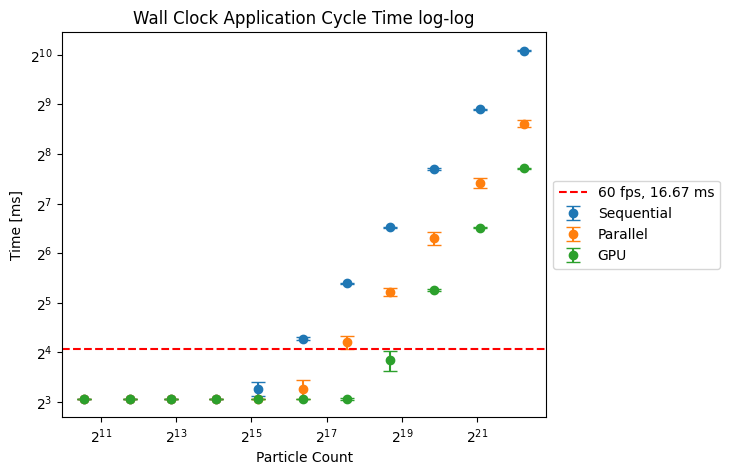

In [22]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(wall_seq["particle_count"], wall_seq["avg_time"], yerr=wall_seq["avg_time_err"], fmt='o', label=f"Sequential", capsize=5)
axs.errorbar(wall_par["particle_count"], wall_par["avg_time"], yerr=wall_par["avg_time_err"], fmt='o', label=f"Parallel", capsize=5)
axs.errorbar(wall_cs["particle_count"], wall_cs["avg_time"], yerr=wall_cs["avg_time_err"], fmt='o', label=f"GPU", capsize=5)

# Red dashed line at 16.67 ms
axs.axhline(y=16.67, color='r', linestyle='--', label="60 fps, 16.67 ms")

axs.set_title("Wall Clock Application Cycle Time log-log")
axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")

axs.set_xscale("log", base=2)
axs.set_yscale("log", base=2)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("wall_clock_log.svg", format="svg")
plt.show()

# The histograms

In [23]:
hist_seq = pd.read_csv('hist_seq.csv')
hist_par = pd.read_csv('hist_par.csv')
hist_cs = pd.read_csv('hist_cs.csv')

particle_counts = [1500, 3500, 7500, 17000, 37000, 85000, 190000, 420000, 950000, 2200000, 5000000]
modes = ["computeShaders", "sequential", "parallel"]

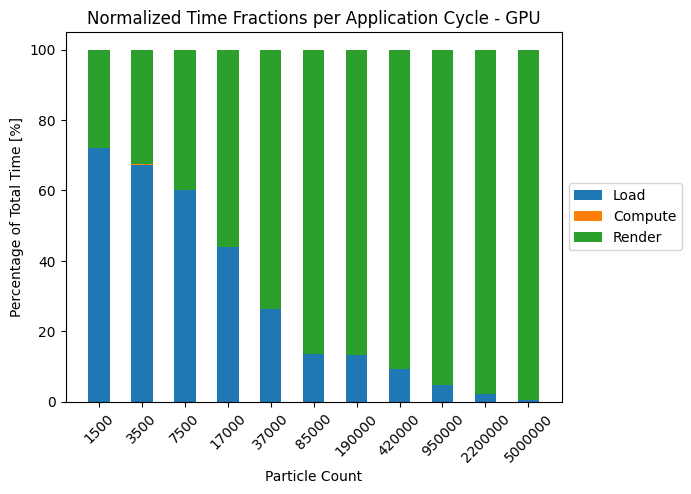

In [24]:
# Stacked bars compute shaders
chunk = 11
species = [str(x) for x in particle_counts[0:chunk]]
weight_counts = {
    "Load": np.array(hist_cs["avg_time_cpu"])[0:chunk] / 2,
    "Compute": np.array(hist_cs["avg_time_compute"])[0:chunk],
    "Render": np.array(hist_cs["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(species))

for key, weight in normalized_weights.items():
    ax.bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

ax.set_ylabel('Percentage of Total Time [%]')
ax.set_xlabel('Particle Count')

ax.set_title('Normalized Time Fractions per Application Cycle - GPU')
plt.xticks(rotation=45)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("hist_cs.svg", format="svg")
plt.show()

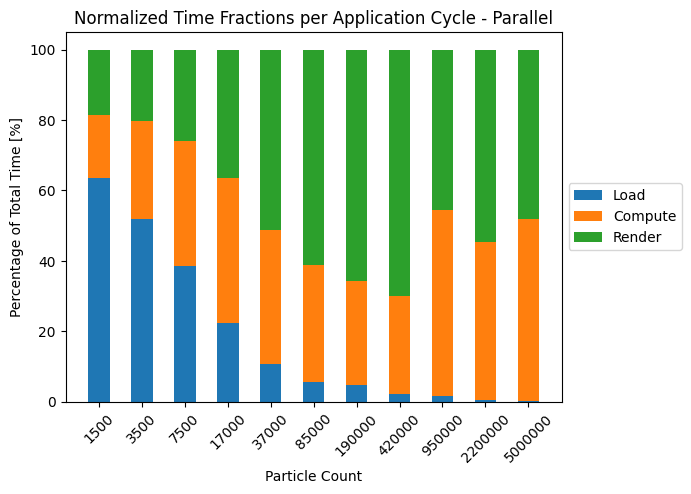

In [25]:
# Stacked bars parallel
chunk = 11
species = [str(x) for x in particle_counts[0:chunk]]
weight_counts = {
    "Load": np.array(hist_par["avg_time_cpu"] - hist_par["avg_time_compute_cpu"])[0:chunk] / 2,
    "Compute": np.array(hist_par["avg_time_compute_cpu"])[0:chunk]/8,
    "Render": np.array(hist_par["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(species))

for key, weight in normalized_weights.items():
    ax.bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

ax.set_ylabel('Percentage of Total Time [%]')
ax.set_xlabel('Particle Count')

ax.set_title('Normalized Time Fractions per Application Cycle - Parallel')
plt.xticks(rotation=45)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("hist_par.svg", format="svg")
plt.show()

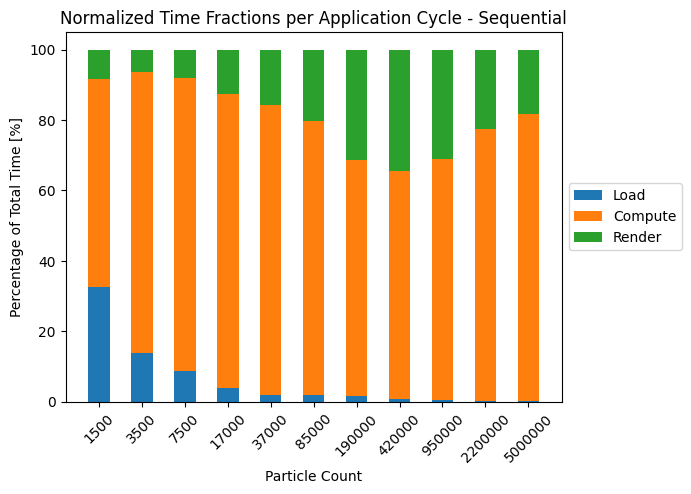

In [26]:
# Stacked bars sequential
chunk = 11
species = [str(x) for x in particle_counts[0:chunk]]
weight_counts = {
    "Load": np.array(hist_seq["avg_time_cpu"] - hist_seq["avg_time_compute_cpu"])[0:chunk] / 2,
    "Compute": np.array(hist_seq["avg_time_compute_cpu"])[0:chunk],
    "Render": np.array(hist_seq["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(species))

for key, weight in normalized_weights.items():
    ax.bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

ax.set_ylabel('Percentage of Total Time [%]')
ax.set_xlabel('Particle Count')
ax.set_title('Normalized Time Fractions per Application Cycle - Sequential')
plt.xticks(rotation=45)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("hist_seq.svg", format="svg")
plt.show()